In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from ydata_profiling import ProfileReport
import warnings

from data_profiling.controller.pandas_decorator import profile_report

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)


In [10]:
dftrain=pd.read_csv("C:/Users/yahia/PycharmProjects/JupyterProject3/data/train.csv")
dftest=pd.read_csv("C:/Users/yahia/PycharmProjects/JupyterProject3/data/test.csv")

In [11]:
dftrain.head()
dftest.head()
dftrain.info()
dftest.info()
dftrain.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43152 entries, 0 to 43151
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Id       43152 non-null  int64  
 1   carat    43152 non-null  float64
 2   cut      43152 non-null  object 
 3   color    43152 non-null  object 
 4   clarity  43152 non-null  object 
 5   depth    43152 non-null  float64
 6   table    43152 non-null  float64
 7   price    43152 non-null  int64  
 8   x        43152 non-null  float64
 9   y        43152 non-null  float64
 10  z        43152 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 3.6+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10788 entries, 0 to 10787
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Id       10788 non-null  int64  
 1   carat    10788 non-null  float64
 2   cut      10788 non-null  object 
 3   color    10788 non-null  object

,Id,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,1.06,Ideal,I,SI2,61.8,57.0,4270,6.57,6.60,4.07
1,2,1.51,Premium,G,VVS2,60.9,58.0,15164,7.38,7.42,4.51
2,3,0.32,Ideal,F,VS2,61.3,56.0,828,4.43,4.41,2.71
3,4,0.53,Ideal,G,VS2,61.2,56.0,1577,5.19,5.22,3.19
4,5,0.70,Premium,H,VVS2,61.0,57.0,2596,5.76,5.72,3.50
...,...,...,...,...,...,...,...,...,...,...,...
43147,43148,0.52,Ideal,E,VS2,61.5,56.0,1760,5.16,5.18,3.18
43148,43149,0.72,Very Good,D,VS2,62.1,59.0,3016,5.70,5.73,3.55
43149,43150,0.44,Premium,I,VVS1,61.5,58.0,990,4.95,4.87,3.02
43150,43151,0.31,Premium,E,VS1,60.2,58.0,734,4.38,4.43,2.65


In [12]:
dftrain.isnull().sum()
dftest.isnull().sum()

Id         0
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
dtype: int64

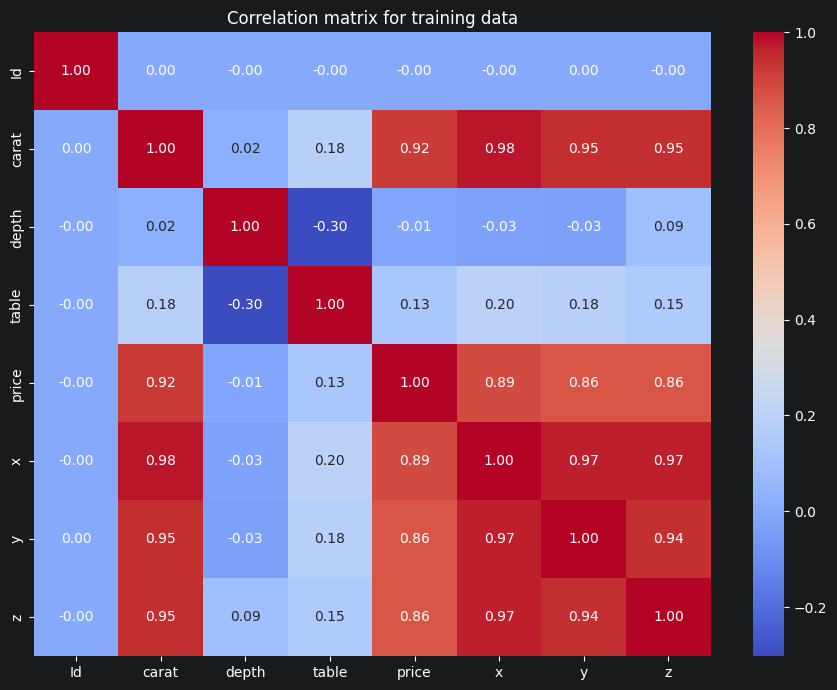

In [13]:
plt.figure(figsize=(9, 7))
sns.heatmap(dftrain.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix for training data')
plt.tight_layout()
plt.show()

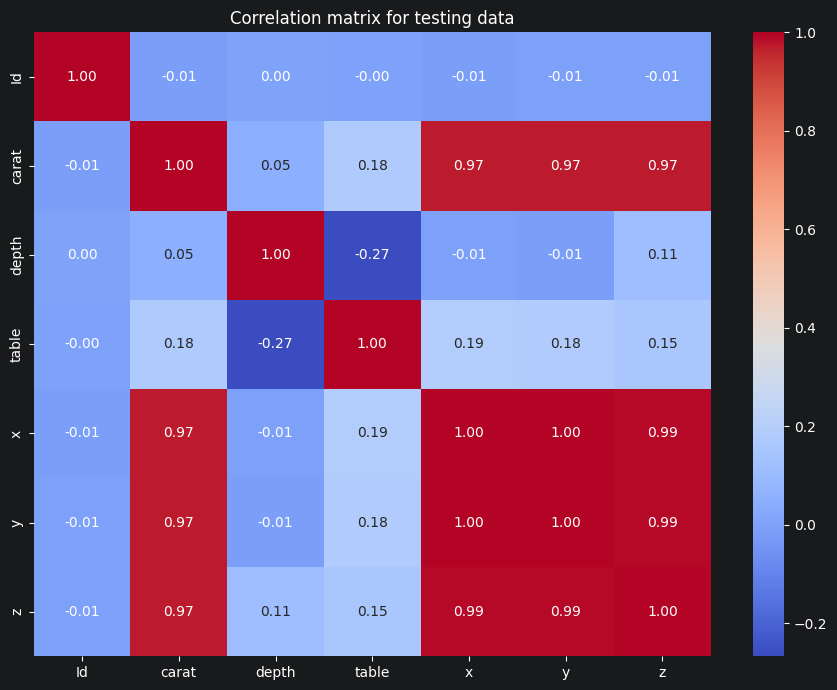

In [14]:
plt.figure(figsize=(9, 7))
sns.heatmap(dftest.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix for testing data')
plt.tight_layout()
plt.show()

In [15]:
print(dftrain.head())

   Id  carat      cut color clarity  depth  table  price     x     y     z
0   1   1.06    Ideal     I     SI2   61.8   57.0   4270  6.57  6.60  4.07
1   2   1.51  Premium     G    VVS2   60.9   58.0  15164  7.38  7.42  4.51
2   3   0.32    Ideal     F     VS2   61.3   56.0    828  4.43  4.41  2.71
3   4   0.53    Ideal     G     VS2   61.2   56.0   1577  5.19  5.22  3.19
4   5   0.70  Premium     H    VVS2   61.0   57.0   2596  5.76  5.72  3.50


In [16]:
dftrain.drop(columns=['Id'], inplace=True)

In [18]:
dftrain.duplicated().sum()

np.int64(97)

In [19]:
dftrain.drop_duplicates(inplace=True)

In [20]:
print(dftrain.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   1.06    Ideal     I     SI2   61.8   57.0   4270  6.57  6.60  4.07
1   1.51  Premium     G    VVS2   60.9   58.0  15164  7.38  7.42  4.51
2   0.32    Ideal     F     VS2   61.3   56.0    828  4.43  4.41  2.71
3   0.53    Ideal     G     VS2   61.2   56.0   1577  5.19  5.22  3.19
4   0.70  Premium     H    VVS2   61.0   57.0   2596  5.76  5.72  3.50


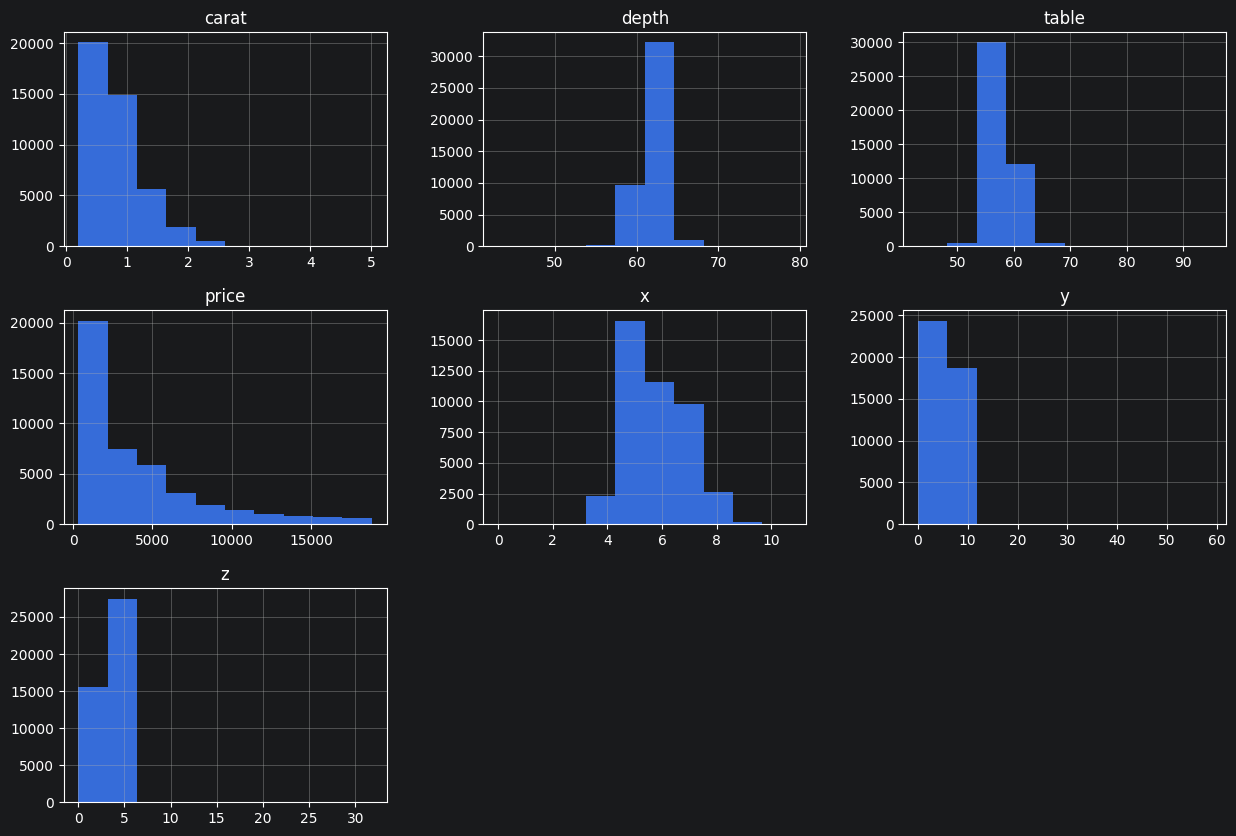

In [24]:
num_cols = dftrain.select_dtypes(include=["int64","float64"]).columns
dftrain[num_cols].hist(figsize=(15,10))
plt.show()

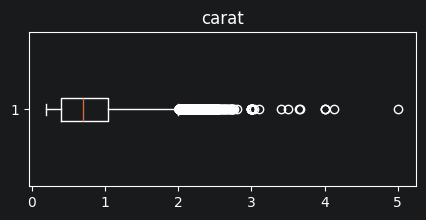

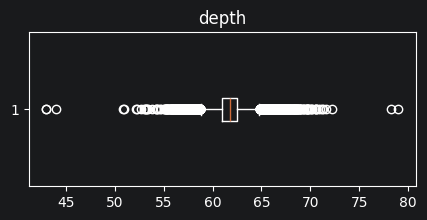

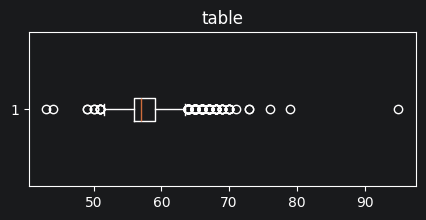

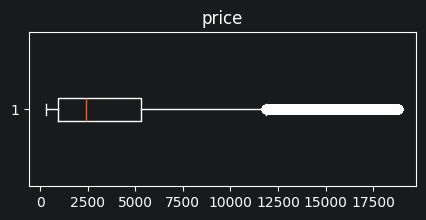

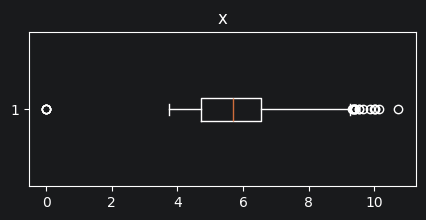

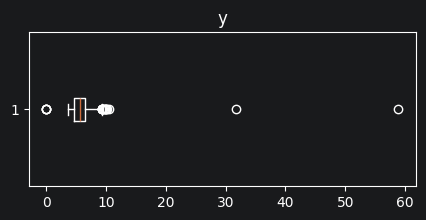

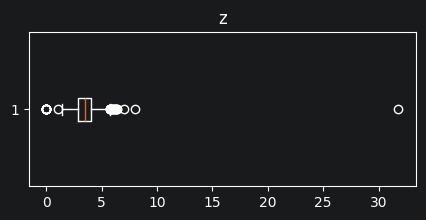

In [25]:
for col in num_cols:
    plt.figure(figsize=(5,2))
    plt.boxplot(dftrain[col], vert=False)
    plt.title(col)
    plt.show()

In [26]:
(dftrain == 0).sum()

carat       0
cut         0
color       0
clarity     0
depth       0
table       0
price       0
x           5
y           4
z          17
dtype: int64

In [27]:
dftrain = dftrain[(dftrain["x"] != 0) & (dftrain["y"] != 0) & (dftrain["z"] != 0)]

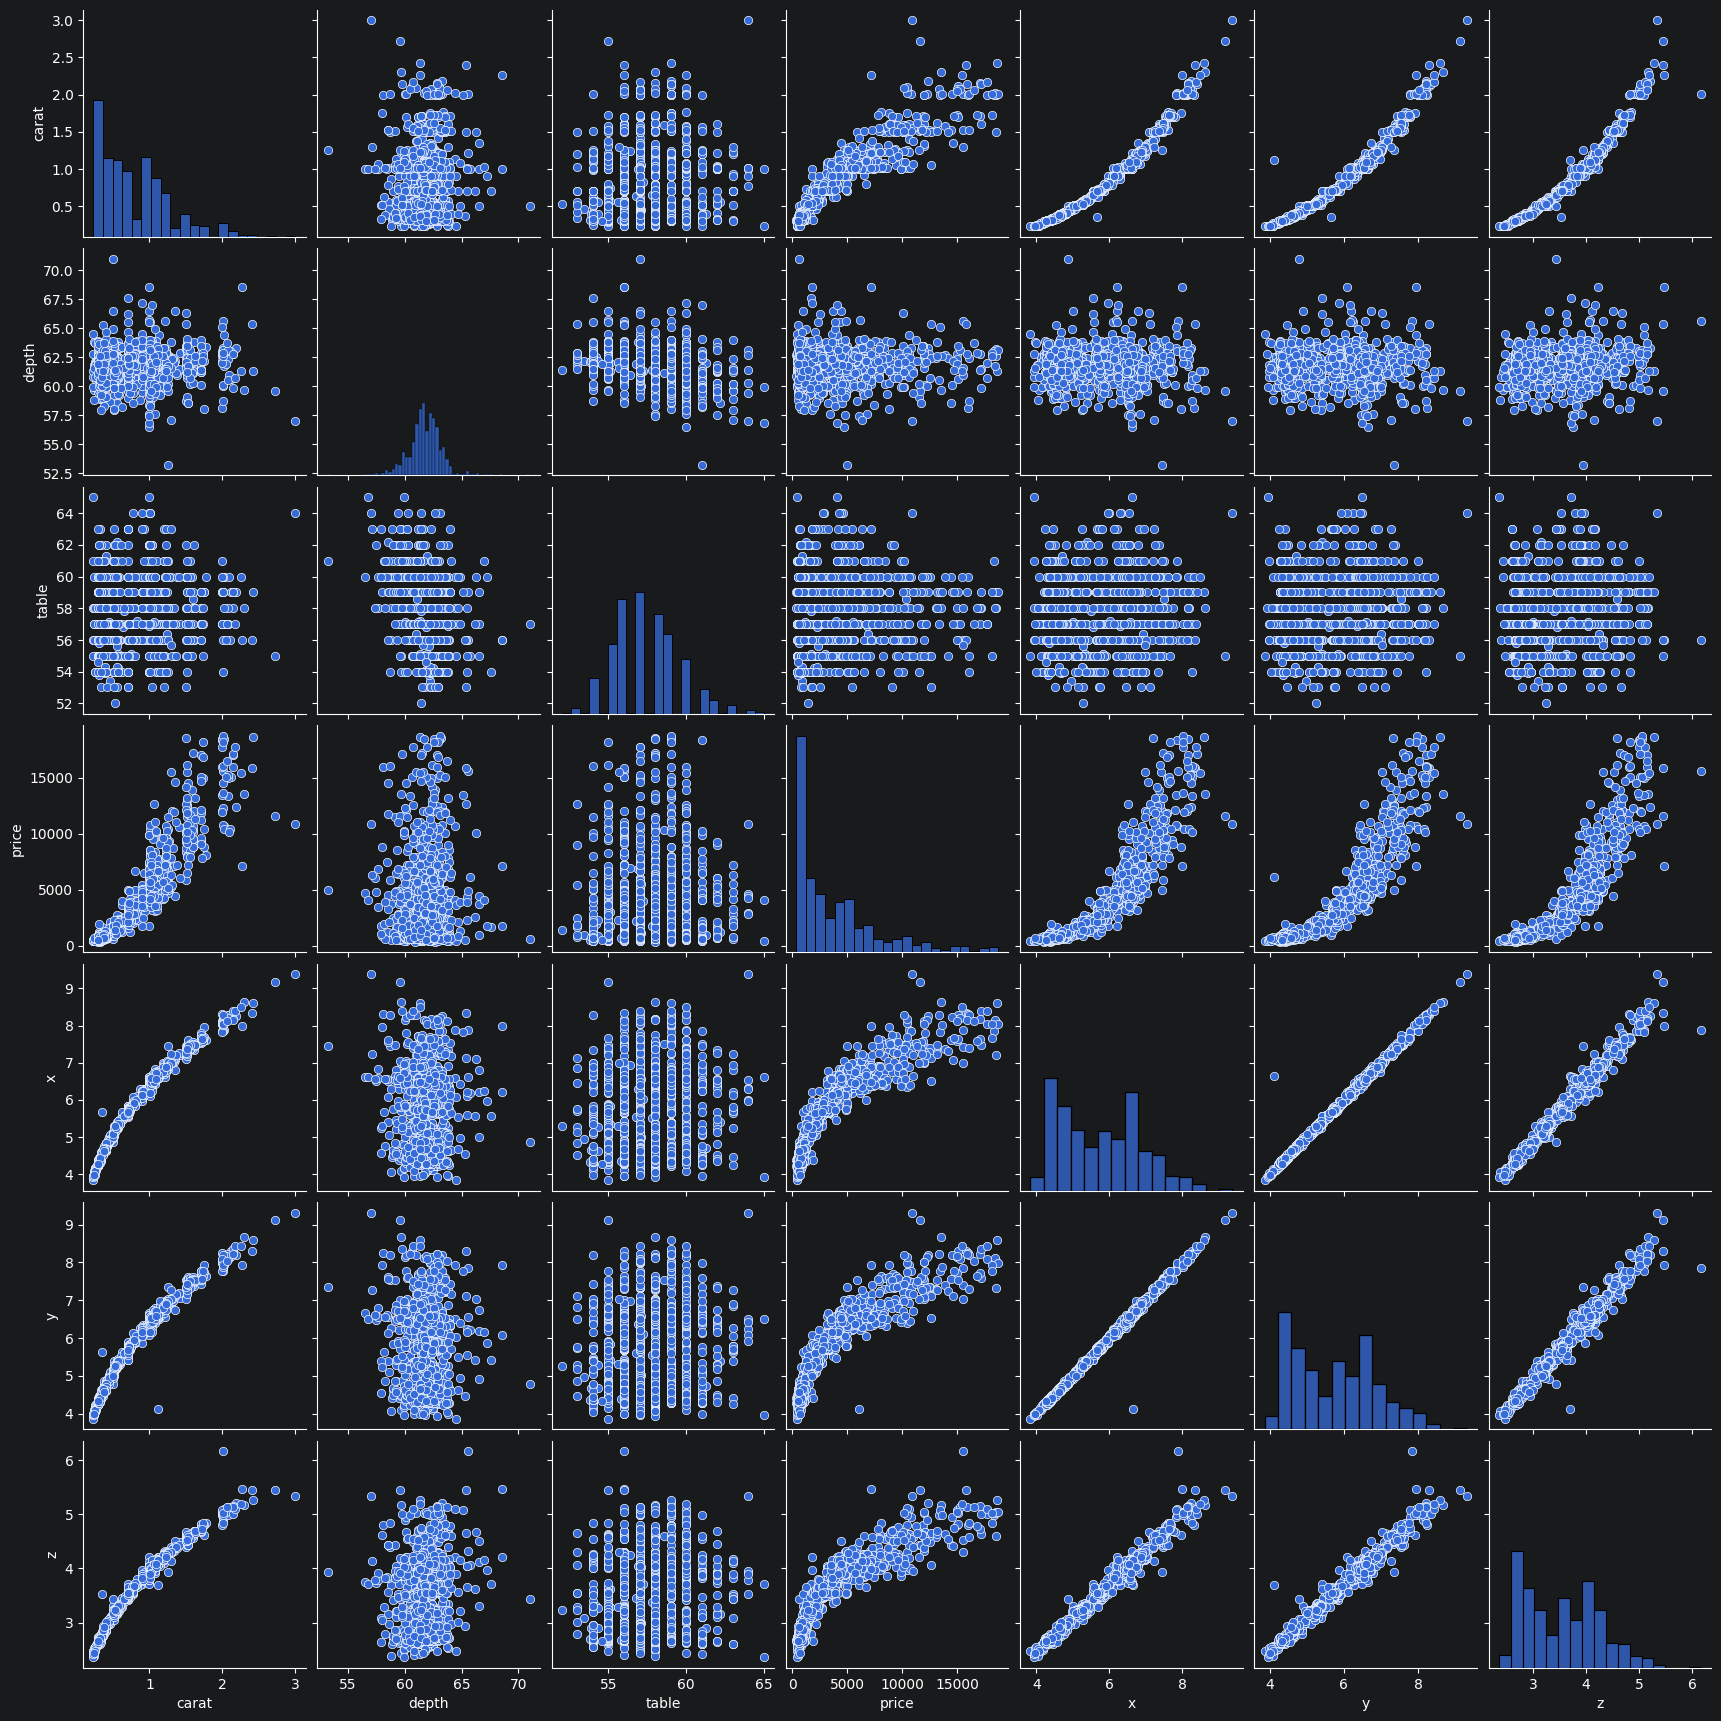

In [28]:
sample = dftrain.sample(1000, random_state=42)

sns.pairplot(sample[["carat","depth","table","price","x","y","z"]])
plt.show()

In [29]:
dftrain.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,1.06,Ideal,I,SI2,61.8,57.0,4270,6.57,6.60,4.07
1,1.51,Premium,G,VVS2,60.9,58.0,15164,7.38,7.42,4.51
2,0.32,Ideal,F,VS2,61.3,56.0,828,4.43,4.41,2.71
3,0.53,Ideal,G,VS2,61.2,56.0,1577,5.19,5.22,3.19
4,0.70,Premium,H,VVS2,61.0,57.0,2596,5.76,5.72,3.50


In [31]:
dftrain = dftrain.drop_duplicates()

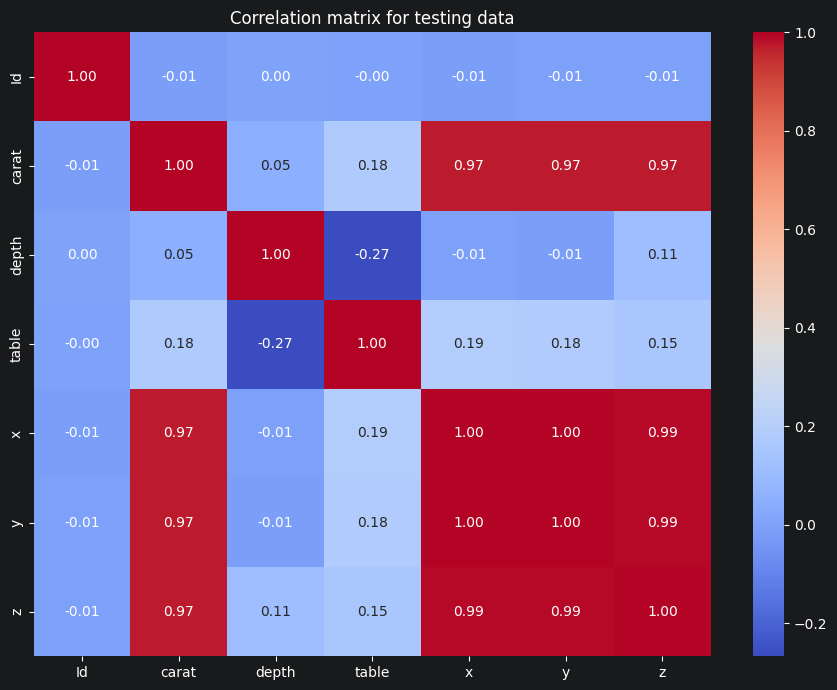

In [32]:
plt.figure(figsize=(9, 7))
sns.heatmap(dftest.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix for testing data')
plt.tight_layout()
plt.show()

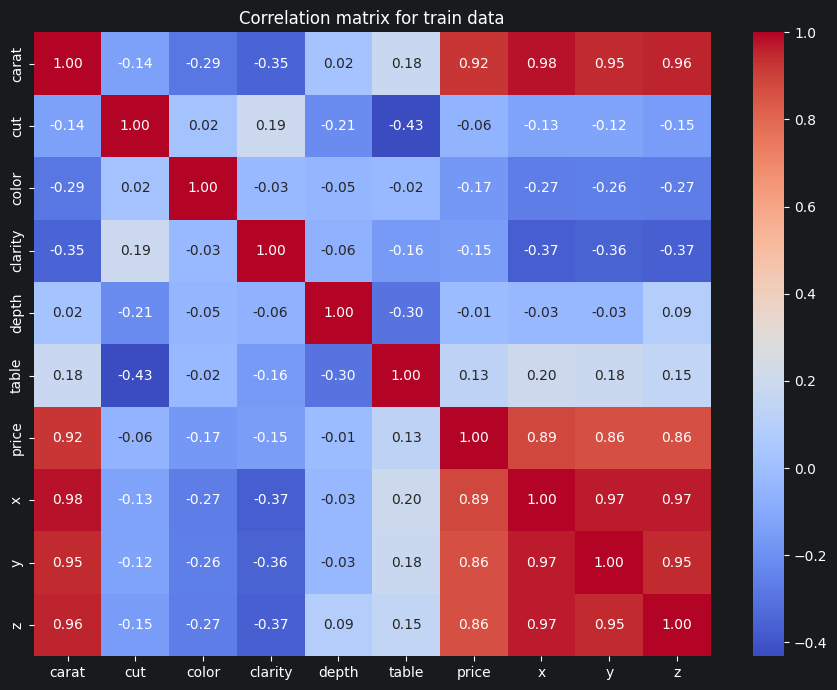

,carat,cut,color,clarity,depth,table,price,x,y,z
0,1.06,4.0,1.0,1.0,61.8,57.0,4270,6.57,6.60,4.07
1,1.51,3.0,3.0,5.0,60.9,58.0,15164,7.38,7.42,4.51
2,0.32,4.0,4.0,3.0,61.3,56.0,828,4.43,4.41,2.71
3,0.53,4.0,3.0,3.0,61.2,56.0,1577,5.19,5.22,3.19
4,0.70,3.0,2.0,5.0,61.0,57.0,2596,5.76,5.72,3.50


In [33]:
from sklearn.preprocessing import OrdinalEncoder

cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

encoder = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])

dftrain[["cut", "color", "clarity"]] = encoder.fit_transform(
    dftrain[["cut", "color", "clarity"]]
)


plt.figure(figsize=(9, 7))
sns.heatmap(dftrain.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix for train data')
plt.tight_layout()
plt.show()
dftrain.head()

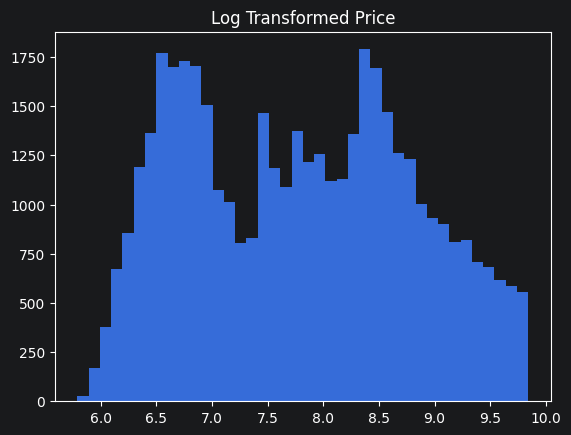

In [34]:
dftrain["price_log"] = np.log1p(dftrain["price"])
plt.hist(dftrain["price_log"], bins=40)
plt.title("Log Transformed Price")
plt.show()

In [35]:
Q1 = dftrain["price_log"].quantile(0.25)
Q3 = dftrain["price_log"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

dftrain["price_log"] = dftrain["price_log"].clip(lower=lower, upper=upper)

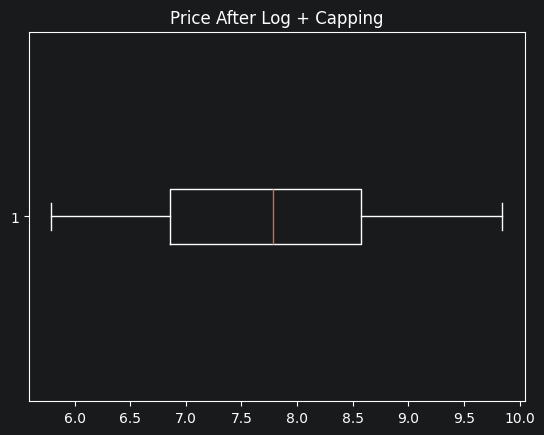

In [36]:
plt.boxplot(dftrain["price_log"], vert=False)
plt.title("Price After Log + Capping")
plt.show()

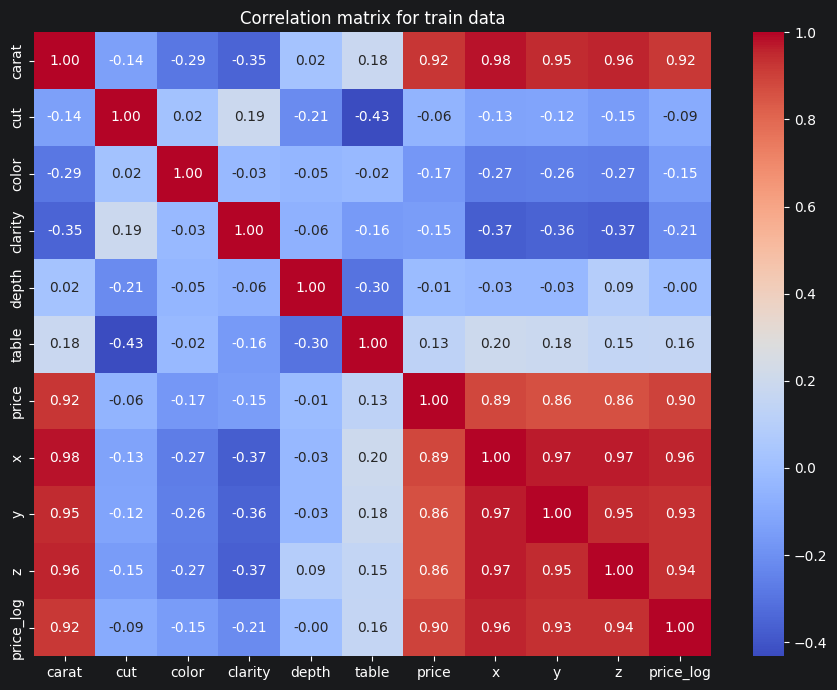

,carat,cut,color,clarity,depth,table,price,x,y,z,price_log
0,1.06,4.0,1.0,1.0,61.8,57.0,4270,6.57,6.60,4.07,8.359603
1,1.51,3.0,3.0,5.0,60.9,58.0,15164,7.38,7.42,4.51,9.626745
2,0.32,4.0,4.0,3.0,61.3,56.0,828,4.43,4.41,2.71,6.720220
3,0.53,4.0,3.0,3.0,61.2,56.0,1577,5.19,5.22,3.19,7.363914
4,0.70,3.0,2.0,5.0,61.0,57.0,2596,5.76,5.72,3.50,7.862112


In [37]:
plt.figure(figsize=(9, 7))
sns.heatmap(dftrain.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix for train data')
plt.tight_layout()
plt.show()
dftrain.head()

In [38]:
dftrain.drop(columns=['price'], inplace=True)

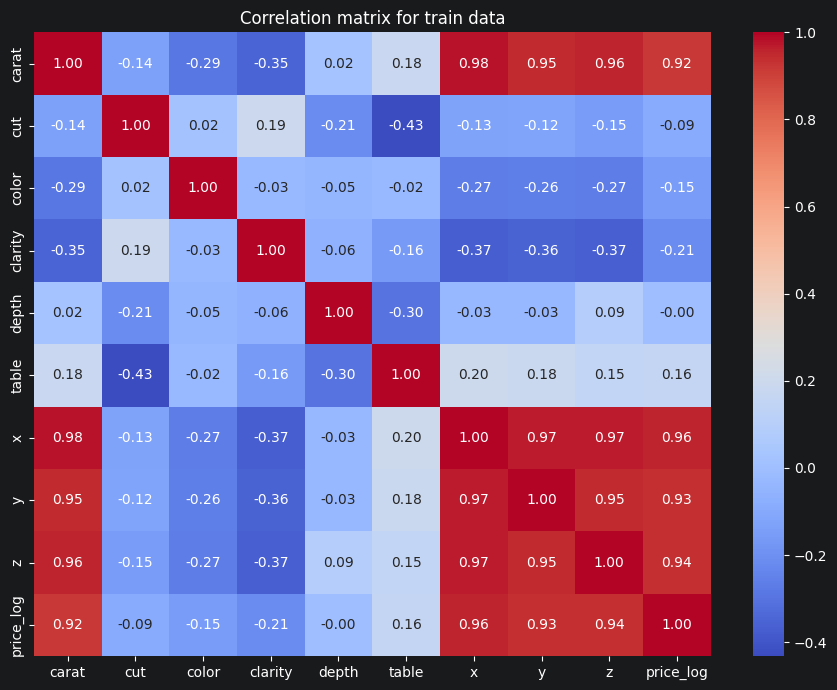

,carat,cut,color,clarity,depth,table,x,y,z,price_log
0,1.06,4.0,1.0,1.0,61.8,57.0,6.57,6.60,4.07,8.359603
1,1.51,3.0,3.0,5.0,60.9,58.0,7.38,7.42,4.51,9.626745
2,0.32,4.0,4.0,3.0,61.3,56.0,4.43,4.41,2.71,6.720220
3,0.53,4.0,3.0,3.0,61.2,56.0,5.19,5.22,3.19,7.363914
4,0.70,3.0,2.0,5.0,61.0,57.0,5.76,5.72,3.50,7.862112


In [41]:
plt.figure(figsize=(9, 7))
sns.heatmap(dftrain.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix for train data')
plt.tight_layout()
plt.show()
dftrain.head()

In [ ]:
# from sklearn.ensemble import RandomForestRegressor
#
# model = RandomForestRegressor(random_state=42)
#
# model.fit(,)
#
# importance = model.feature_importances_
#
# feature_importance = (
#     pd.DataFrame({
#         "Feature": X.columns,
#         "Importance": importance
#     })
#     .sort_values("Importance", ascending=False)
# )
#
# print(feature_importance)

In [45]:
dftrain["volume"] = dftrain["x"] * dftrain["y"] * dftrain["z"]
dftrain.drop(columns=["x", "y", "z"], inplace=True)

In [46]:
dftrain.head()

,carat,cut,color,clarity,depth,table,price_log,volume
0,1.06,4.0,1.0,1.0,61.8,57.0,8.359603,176.483340
1,1.51,3.0,3.0,5.0,60.9,58.0,9.626745,246.965796
2,0.32,4.0,4.0,3.0,61.3,56.0,6.720220,52.943373
3,0.53,4.0,3.0,3.0,61.2,56.0,7.363914,86.422842
4,0.70,3.0,2.0,5.0,61.0,57.0,7.862112,115.315200


In [47]:
dftrain.head(1000)

,carat,cut,color,clarity,depth,table,price_log,volume
0,1.06,4.0,1.0,1.0,61.8,57.0,8.359603,176.483340
1,1.51,3.0,3.0,5.0,60.9,58.0,9.626745,246.965796
2,0.32,4.0,4.0,3.0,61.3,56.0,6.720220,52.943373
3,0.53,4.0,3.0,3.0,61.2,56.0,7.363914,86.422842
4,0.70,3.0,2.0,5.0,61.0,57.0,7.862112,115.315200
...,...,...,...,...,...,...,...,...
997,0.50,4.0,5.0,3.0,61.5,57.0,7.393263,82.736010
998,1.12,2.0,1.0,3.0,62.9,55.9,8.565983,181.483328
999,0.70,4.0,1.0,3.0,62.2,55.0,7.711101,113.685062
1000,1.18,2.0,3.0,2.0,60.8,58.0,8.746239,193.591275


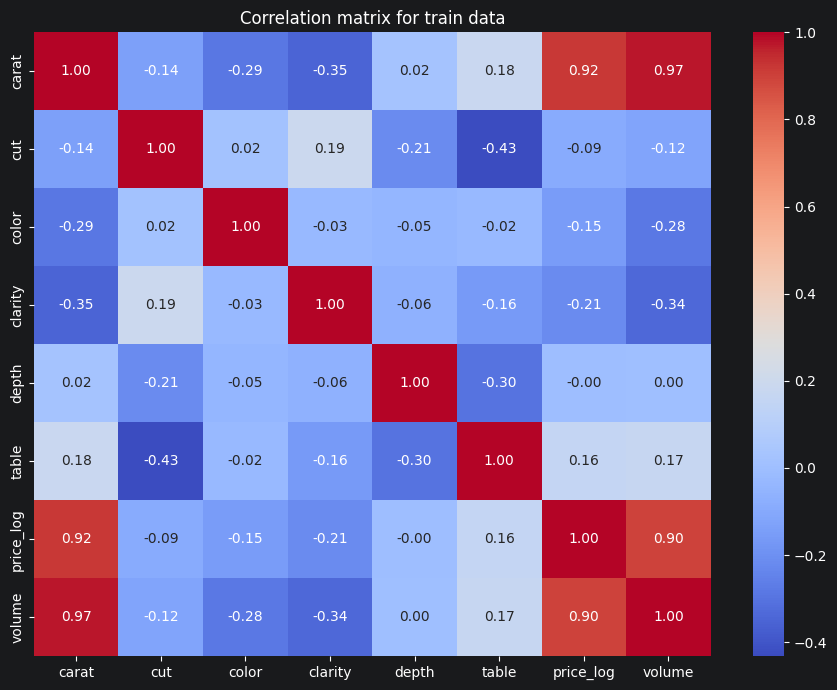

,carat,cut,color,clarity,depth,table,price_log,volume
0,1.06,4.0,1.0,1.0,61.8,57.0,8.359603,176.483340
1,1.51,3.0,3.0,5.0,60.9,58.0,9.626745,246.965796
2,0.32,4.0,4.0,3.0,61.3,56.0,6.720220,52.943373
3,0.53,4.0,3.0,3.0,61.2,56.0,7.363914,86.422842
4,0.70,3.0,2.0,5.0,61.0,57.0,7.862112,115.315200


In [48]:
plt.figure(figsize=(9, 7))
sns.heatmap(dftrain.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix for train data')
plt.tight_layout()
plt.show()
dftrain.head()

In [49]:
profile=profile_report(dftrain)
profile

NameError: name 'profile_report' is not defined